В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df['smoker'] == 'no']

x = non_smoker_df['age'].to_numpy()
y = non_smoker_df['charges'].to_numpy()

X_mnk = np.column_stack((np.ones(len(x)), x))

X_sklearn = non_smoker_df[['age']]

print('Кількість некурців:', len(non_smoker_df))
print('Розмір X_mnk:', X_mnk.shape)

Кількість некурців: 1064
Розмір X_mnk: (1064, 2)


In [ ]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

In [ ]:
def normal_equations(X, y):
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

theta_mnk = normal_equations(X_mnk, y)

b_mnk = theta_mnk[0]
w_mnk = theta_mnk[1]

predictions_mnk = X_mnk.dot(theta_mnk)
rmse_mnk = rmse(y, predictions_mnk)

print('МНК')
print('w =', w_mnk)
print('b =', b_mnk)
print('RMSE =', rmse_mnk)

МНК
w = 267.2489128311998
b = -2091.4205565650805
RMSE = 4662.505766636395


In [ ]:
def full_batch_gradient_descent(X, y, learning_rate, epochs):
    theta = np.zeros(X.shape[1])
    losses = []

    for _ in range(epochs):
        predictions = X.dot(theta)
        errors = predictions - y

        with np.errstate(over='ignore', invalid='ignore'):
          mse = np.mean(errors ** 2)

        if not np.isfinite(mse):
            return theta, np.array(losses), False

        losses.append(mse)

        gradient = (2 / len(y)) * X.T.dot(errors)
        theta = theta - learning_rate * gradient

        if not np.all(np.isfinite(theta)):
            return theta, np.array(losses), False

    return theta, np.array(losses), True

In [ ]:
settings = [
    (0.1, 1000),
    (0.0001, 200_000),
    (0.00001, 200_000)
]

gd_results = {}

for learning_rate, epochs in settings:
    theta_gd, losses, finished = full_batch_gradient_descent(
        X_mnk, y, learning_rate, epochs
    )

    if finished:
        b_gd = theta_gd[0]
        w_gd = theta_gd[1]

        predictions_gd = X_mnk @ theta_gd
        rmse_gd = rmse(y, predictions_gd)

        gd_results[learning_rate] = {
            'w': w_gd,
            'b': b_gd,
            'predictions': predictions_gd,
            'losses': losses,
            'rmse': rmse_gd,
            'finished': True
        }

        print(f'\nlearning rate = {learning_rate}')
        print('w =', w_gd)
        print('b =', b_gd)
        print('RMSE =', rmse_gd)

    else:
        gd_results[learning_rate] = {
            'losses': losses,
            'finished': False
        }

        print(f'\nlearning rate = {learning_rate}')
        print('Градієнтний спуск розійшовся.')


learning rate = 0.1
Градієнтний спуск розійшовся.

learning rate = 0.0001
w = 266.7393863144744
b = -2068.7906105520456
RMSE = 4662.511987422228

learning rate = 1e-05
w = 237.23824121686818
b = -758.5362882205861
RMSE = 4684.0366468426355


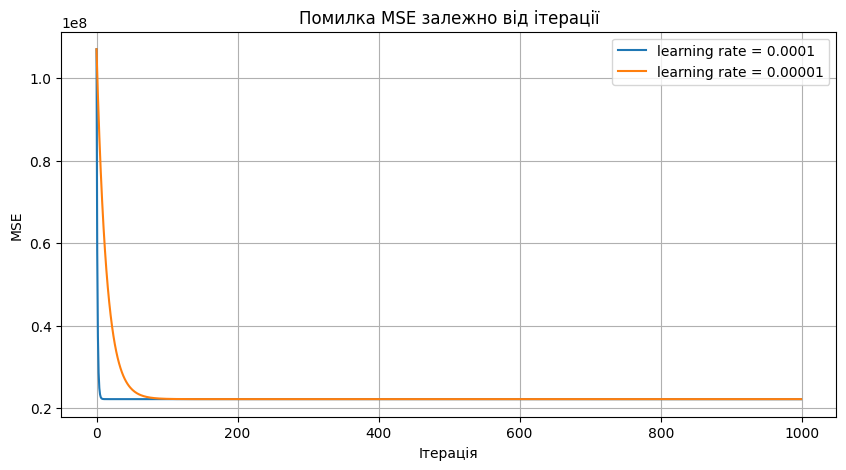

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    gd_results[0.0001]['losses'][:1000],
    label='learning rate = 0.0001'
)

plt.plot(
    gd_results[0.00001]['losses'][:1000],
    label='learning rate = 0.00001'
)

plt.title('Помилка MSE залежно від ітерації')
plt.xlabel('Ітерація')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model_sklearn = LinearRegression()

model_sklearn.fit(X_sklearn, y)

w_sklearn = model_sklearn.coef_[0]
b_sklearn = model_sklearn.intercept_

predictions_sklearn = model_sklearn.predict(X_sklearn)
rmse_sklearn = rmse(y, predictions_sklearn)

print('Sklearn')
print('w =', w_sklearn)
print('b =', b_sklearn)
print('RMSE =', rmse_sklearn)

Sklearn
w = 267.2489128311997
b = -2091.4205565650864
RMSE = 4662.505766636395


In [ ]:
valid_learning_rates = [
    lr for lr in gd_results
    if gd_results[lr]['finished']
]

best_lr = min(
    valid_learning_rates,
    key=lambda lr: gd_results[lr]['rmse']
)

best_gd = gd_results[best_lr]

print('Найкращий learning rate:', best_lr)
print('RMSE:', best_gd['rmse'])

Найкращий learning rate: 0.0001
RMSE: 4662.511987422228


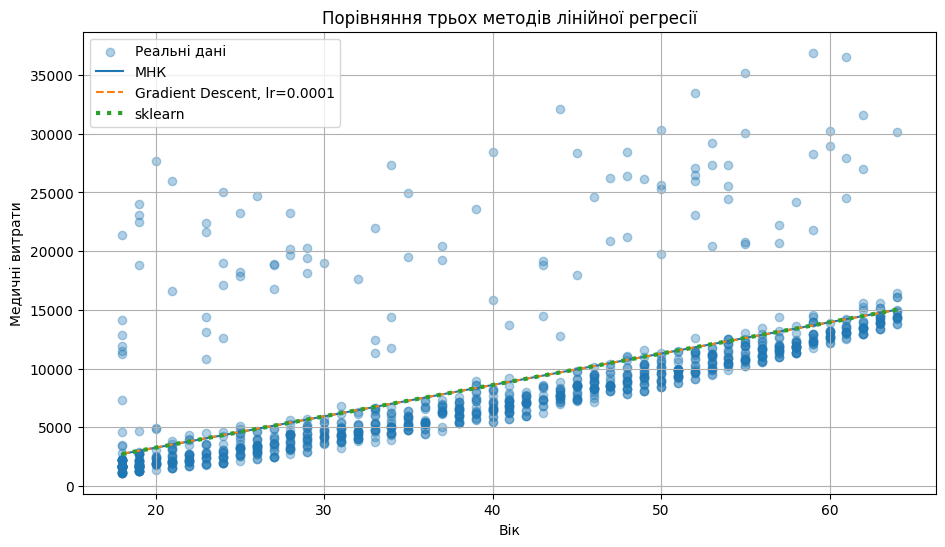

In [ ]:
sort_index = np.argsort(x)

plt.figure(figsize=(11, 6))

plt.scatter(x, y, alpha=0.35, label='Реальні дані')

plt.plot(
    x[sort_index],
    predictions_mnk[sort_index],
    label='МНК'
)

plt.plot(
    x[sort_index],
    best_gd['predictions'][sort_index],
    linestyle='--',
    label=f'Gradient Descent, lr={best_lr}'
)

plt.plot(
    x[sort_index],
    predictions_sklearn[sort_index],
    linestyle=':',
    linewidth=3,
    label='sklearn'
)

plt.title('Порівняння трьох методів лінійної регресії')
plt.xlabel('Вік')
plt.ylabel('Медичні витрати')
plt.legend()
plt.grid(True)

plt.show()

`Висновок:`

> За методом найменших квадратів було отримано коефіцієнти w = 267 та b = -2091. Це означає, що зі збільшенням віку на один рік прогнозовані медичні витрати зростають у середньому приблизно на 267 одиниць. RMSE моделі становить приблизно 4663

> Модель `sklearn.LinearRegression` дала такі самі або майже такі самі значення коефіцієнтів і RMSE, як і МНК. Це очікувано, оскільки обидва методи знаходять оптимальну пряму для лінійної регресії.

> Для градієнтного спуску було перевірено три значення `learning_rate`. При `learning_rate = 0.1` алгоритм розійшовся, оскільки крок був занадто великим. При меншому значенні `learning_rate` модель поступово наближалася до результату МНК. Найкращий з перевірених варіантів дав коефіцієнти, близькі до w = approx 267 та b = -2091, і RMSE, близький до 4663.

Отже, усі три методи описують практично одну й ту саму залежність між віком та медичними витратами. Проте RMSE близько 4663 показує, що лише віку недостатньо для точного прогнозування `charges`, оскільки на витрати впливають також інші фактори.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [ ]:
smoker_df = medical_df[medical_df['smoker'] == 'yes']

X_smoker = smoker_df[['age']]
y_smoker = smoker_df['charges']

print('Кількість курців:', len(smoker_df))
print(X_smoker.head())
print(y_smoker.head())

Кількість курців: 274
    age
0    19
11   62
14   27
19   30
23   34
0     16884.9240
11    27808.7251
14    39611.7577
19    36837.4670
23    37701.8768
Name: charges, dtype: float64


In [ ]:
model_smoker = LinearRegression()

model_smoker.fit(X_smoker, y_smoker)

w_smoker = model_smoker.coef_[0]
b_smoker = model_smoker.intercept_

predictions_smoker = model_smoker.predict(X_smoker)

r2_smoker = model_smoker.score(X_smoker, y_smoker)
rmse_smoker = rmse(y_smoker, predictions_smoker)

print('w =', w_smoker)
print('b =', b_smoker)
print('R² =', r2_smoker)
print('RMSE =', rmse_smoker)

w = 305.2376021098288
b = 20294.128126915966
R² = 0.13558924096084068
RMSE = 10711.00334810241


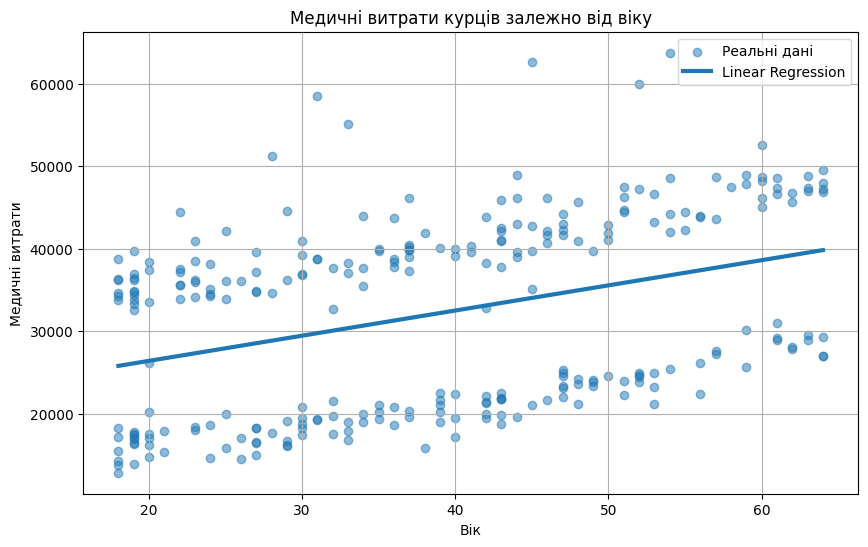

In [ ]:
sort_index = np.argsort(X_smoker['age'].to_numpy())

plt.figure(figsize=(10, 6))

plt.scatter(
    X_smoker['age'],
    y_smoker,
    alpha=0.5,
    label='Реальні дані'
)

plt.plot(
    X_smoker['age'].to_numpy()[sort_index],
    predictions_smoker[sort_index],
    linewidth=3,
    label='Linear Regression'
)

plt.title('Медичні витрати курців залежно від віку')
plt.xlabel('Вік')
plt.ylabel('Медичні витрати')
plt.legend()
plt.grid(True)

plt.show()

`Висновок:`

Було отримано такі результати: w = 305.24, b = 20294.13, R² = 0.136, RMSE = 10711.

Коефіцієнт w показує, що зі збільшенням віку на один рік прогнозовані медичні витрати курця в середньому збільшуються приблизно на 305 одиниць.

Проте модель не є дуже точною. Значення R² = 0.136 означає, що вік пояснює лише приблизно 13.6% різниці в медичних витратах курців. Також RMSE є досить великим - приблизно 10711, тобто модель може сильно помилятися у прогнозах.

Тому я б не використовувала таку модель у компанії.